In [1]:
from scipy import sparse
from ase.build import molecule
from ase.neighborlist import get_connectivity_matrix
from ase.neighborlist import natural_cutoffs
from ase.neighborlist import NeighborList
import ase
import numpy as np
from ase.io import read
from ase import Atoms
import ase.visualize
from ase.visualize.plot import plot_atoms
from cell2mol.read_write import readinfo
from cell2mol.cell_operations import frac2cart_fromparam, cart2frac
import nglview
from ase.build import molecule
from ase.neighborlist import NeighborList
import matplotlib.pyplot as plt

In [2]:
folder = "error_2"
name = "BOFFOS"
infopath = f"{folder}/{name}/{name}.info"
input_path = f"{folder}/{name}/{name}.cif"

In [3]:
atoms = read(input_path)
cell_labels = atoms.get_chemical_symbols()
cell_pos = atoms.positions
cell_fracs = atoms.get_scaled_positions()
cell_vector = atoms.cell.array
# cell_parameters = atoms.cell.cellpar()
space_group = atoms.info['spacegroup']
sym_ops = space_group.get_op()

/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 59 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 60 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 61 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 62 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 63 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3

In [4]:
from cell2mol.classes import cell

labels, pos, ref_labels, ref_fracs, cellvec, cell_param = readinfo(infopath)
# labels, pos, and cellvec will not be used
ref_pos = frac2cart_fromparam(ref_fracs, cell_param)
refcell = cell(name, ref_labels, ref_pos, ref_fracs, cell_vector, cell_param)
refcell.get_subtype("reference")
refcell.get_reference_molecules(ref_labels, ref_fracs)

#########################################
  GETREFS: Generate reference molecules  
#########################################
GETREFS: found 10 reference molecules
GETREFS: ['C6-O12-Fe', 'H24-C12-O6', 'H2-O', 'H2-O', 'H2-O', 'H24-C12-O6', 'H24-C12-O6', 'K', 'K', 'K']
GETREFS: [------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
 

In [5]:
if not refcell.has_isolated_H:  
    refcell.check_missing_H()                                     
refcell.assess_errors(ref=True)

Adjacency [8, 10, 18] ['O', 'O', 'C']
Adjacency [12, 13, 16] ['O', 'O', 'C']
Adjacency [7, 9, 17] ['O', 'O', 'C']
Adjacency [11, 14, 15] ['O', 'O', 'C']
Adjacency [1, 2, 6] ['O', 'O', 'C']
Adjacency [3, 4, 5] ['O', 'O', 'C']
Adjacency [0, 7, 8, 9] ['O', 'H', 'H', 'C']
Adjacency [1, 6, 10, 11] ['O', 'C', 'H', 'H']
Adjacency [1, 13, 14, 15] ['O', 'H', 'H', 'C']
Adjacency [2, 12, 16, 17] ['O', 'C', 'H', 'H']
Adjacency [2, 19, 20, 21] ['O', 'H', 'H', 'C']
Adjacency [3, 18, 22, 23] ['O', 'C', 'H', 'H']
Adjacency [3, 25, 26, 27] ['O', 'H', 'H', 'C']
Adjacency [4, 24, 28, 29] ['O', 'C', 'H', 'H']
Adjacency [4, 31, 32, 33] ['O', 'H', 'H', 'C']
Adjacency [5, 30, 34, 35] ['O', 'C', 'H', 'H']
Adjacency [5, 37, 38, 39] ['O', 'H', 'H', 'C']
Adjacency [0, 36, 40, 41] ['O', 'C', 'H', 'H']
Adjacency [0, 7, 8, 9] ['O', 'H', 'H', 'C']
Adjacency [1, 6, 10, 11] ['O', 'C', 'H', 'H']
Adjacency [1, 13, 14, 15] ['O', 'H', 'H', 'C']
Adjacency [2, 12, 16, 17] ['O', 'C', 'H', 'H']
Adjacency [2, 19, 20, 21] ['O',

In [6]:
for ref in refcell.refmoleclist:
    if ref.iscomplex :
        print(ref.formula, [p.subtype for p in ref.parents], [p_idx for p_idx in ref.parents_indices])
        # for met in ref.metals:
        #     print("--", met.label, [p.subtype for p in met.parents], [p_idx for p_idx in met.parents_index])
        #     # for g in met.groups:
            #     print(g.formula, [p.subtype for p in g.parents], [p_idx for p_idx in g.parents_indices])
        
        for lig in ref.ligands:
            print("--", lig.formula, lig.origin, [p.subtype for p in lig.parents], [p_idx for p_idx in lig.parents_indices])
            # for a in lig.atoms:
            #     print(a.label, [p.subtype for p in a.parents], [p_idx for p_idx in a.parents_index])
            # for g in lig.groups:
            #     print(g.formula, [p.subtype for p in g.parents], [p_idx for p_idx in g.parents_indices])
    # else :
    #     print(ref.formula, [p.subtype for p in ref.parents], [p_idx for p_idx in ref.parents_indices])
    # print("")

C6-O12-Fe ['reference'] [[1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]]
-- C2-O4 split_complex ['molecule', 'reference'] [[8, 10, 12, 13, 16, 18], [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]]
-- C2-O4 split_complex ['molecule', 'reference'] [[7, 9, 11, 14, 15, 17], [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]]
-- C2-O4 split_complex ['molecule', 'reference'] [[1, 2, 3, 4, 5, 6], [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]]


In [7]:
refcell

------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = reference
 Name (Refcode)        = BOFFOS
 Num Atoms             = 157
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
---------------------------------------------------
 # of Ref Molecules:   = 10
 With Formulae:                                  
    0: C6-O12-Fe 
    1: H24-C12-O6 
    2: H2-O 
    3: H2-O 
    4: H2-O 
    5: H24-C12-O6 
    6: H24-C12-O6 
    7: K 
    8: K 
    9: K 

In [8]:
refcell.get_unique_species()

Getting unique species in cell


[------------- Cell2mol LIGAND Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 6
  Formula                      = C2-O4
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
  Number of Groups             = 2
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 2.0
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 6
  Regular Adjacencies (connec) = 6
 ----------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type             

In [9]:
refcell.unique_species

[------------- Cell2mol LIGAND Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 6
  Formula                      = C2-O4
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
  Number of Groups             = 2
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 2.0
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 6
  Regular Adjacencies (connec) = 6
 ----------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type             

In [10]:
refcell.unique_indices

[0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]

In [11]:
debug = 2

In [12]:
selected_cs = []
for idx, specie in enumerate(refcell.unique_species):
    tmp = specie.get_possible_cs(debug=debug)
    if tmp is None: 
        print("error")
    if specie.subtype != "metal":
        selected_cs.append(list([cs.corr_total_charge for cs in specie.possible_cs]))
    else :
        selected_cs.append(specie.possible_cs)   

    GET_PROTONATION_STATES: Evaluating group O with parent_indices [2]
        GET_PROTONATION_STATES: evaluating non-haptic group with index 2 and label O
    GET_PROTONATION_STATES: Evaluating group O with parent_indices [1]
        GET_PROTONATION_STATES: evaluating non-haptic group with index 1 and label O
        GET_PROTONATION_STATES:protonation_states=[------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'O', 'O', 'O', 'C', 'C']
 Type                            = Local
 Atoms added in positions        = [0 0 0 0 0 0]
 Atoms blocked (no atoms added)  = [0 1 1 0 0 0]
---------------------------------------------------
]
    POSCHARGE will try charges [0, -1, 1, -2, 2, -3, 3, -4, 4]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with

In [13]:
selected_cs

[[-2], [2, 3], [0], [0], [1]]

In [14]:
from cell2mol.charge_assignment import balance_charge
final_charge_distribution, final_charges = balance_charge(refcell.unique_indices, refcell.unique_species, debug=debug)

BALANCE: iterlist [[-2], [2, 3], [0], [0], [1]]
BALANCE: unique_indices [0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]
BALANCE: tmpdistr [(-2, 2, 0, 0, 1), (-2, 3, 0, 0, 1)]
BALANCE: alldistr added: [-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: alldistr added: [-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]


In [15]:
final_charge_distribution

[[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]]

In [16]:
final_charges

[(-2, 3, 0, 0, 1)]

In [40]:
for specie, final_charge in zip(refcell.unique_species, final_charges[0]):
    print(specie.unique_index, specie.formula)
    if (specie.subtype == "molecule" and specie.iscomplex == False) or (specie.subtype == "ligand"):
        charge_list = [cs.corr_total_charge for cs in specie.possible_cs]
        idx = charge_list.index(final_charge)
        cs = specie.possible_cs[idx]
        specie.charge_state = cs
        # print(specie.charge_state.protonation)
        specie.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)
    elif specie.subtype == "metal" :
        charge_list = specie.possible_cs   
        idx = charge_list.index(final_charge)
        cs = specie.possible_cs[idx]
        specie.set_charge(cs) 
    # print(specie)

0 C2-O4
1 Fe
2 H24-C12-O6
3 H2-O
4 K


C2-O4 canonical smiles: O=C([O-])C(=O)[O-]


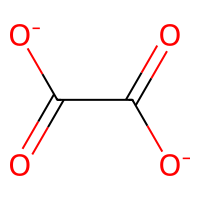

H24-C12-O6 canonical smiles: [H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC1([H])[H]


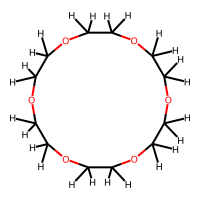

H2-O canonical smiles: [H]O[H]


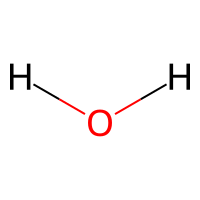

K canonical smiles: [K+]


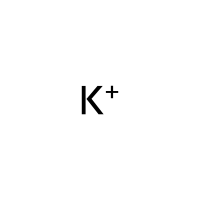

In [41]:
from IPython.display import display
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = False
IPythonConsole.molSize = 200,200
from rdkit import Chem
from cell2mol.connectivity import create_bonds_spicie

for specie, final_charge in zip(refcell.unique_species, final_charges[0]):
    if (specie.subtype == "molecule" and specie.iscomplex == False) or (specie.subtype == "ligand"):
        create_bonds_spicie(specie, debug=0)
        print(specie.formula, "canonical smiles:", Chem.MolToSmiles(specie.rdkit_obj, canonical=True))
        display(specie.rdkit_obj)

In [19]:
for ref in refcell.refmoleclist:
    print(ref)

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-O6
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge                 = 0
 Smiles                       = [H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])

In [42]:
from cell2mol.xyz2mol import xyz2mol
def get_charge_test(charge: int, prot: object, allow: bool=True, debug: int=0): 
    ## Generates the connectivity of a molecule given a desired charge (charge).
    # The molecule is described by a protonation states that has labels, and the atomic cartesian coordinates "coords"
    # The adjacency matrix is also provided in the protonation state(adjmat)
    #:return charge_state which is an object with the necessary information for other functions to handle the result

    natoms = prot.natoms
    atnums = prot.atnums

    # prot.coords and prot.cov_factor will not be used
    mols = xyz2mol(atnums, prot.coords, prot.adjmat, prot.cov_factor, charge=charge, allow_charged_fragments=allow)
    print(f"GET_CHARGE.{len(mols)=} received from xyz2mol with charge {charge}")
    
    if len(mols) > 1: print("WARNING: More than 1 mol received from xyz2mol for initcharge:", charge)

    # Smiles are generated with rdkit
    smiles = Chem.MolToSmiles(mols[0])
    if debug >= 2: print(f"GET_CHARGE. {smiles=}")
    # Gets the resulting charges
    atom_charge = []
    total_charge = 0
    for i in range(natoms):
        a = mols[0].GetAtomWithIdx(i)  # Returns a particular Atom
        atom_charge.append(a.GetFormalCharge())
        total_charge += a.GetFormalCharge()

    # Connectivity is checked
    iscorrect = check_rdkit_obj_connectivity(mols[0], prot.natoms, charge, debug=debug)

    # Charge_state is initiated
    ch_state = charge_state(iscorrect, total_charge, atom_charge, mols[0], smiles, charge, allow, prot)

    return ch_state

In [43]:
import py3Dmol

def draw_with_spheres(mol):
    v = py3Dmol.view(width=300,height=300)
    IPythonConsole.addMolToView(mol,v)
    v.zoomTo()
    v.setStyle({'sphere':{'radius':0.3},'stick':{'radius':0.2}});
    v.show()

In [41]:
def arrange_data_for_reorder(reference: object, target: object, debug: int=0):
    # To do the reorder, we create new tags that include as much information as possible.
    # Ideally, we aim to include the label + the connectivity + the metal connectivity
    t_totconnec = 0
    t_totmconnec = 0
    for a in target.atoms:
        t_totconnec  += a.connec
        t_totmconnec += a.mconnec
    r_totconnec = 0
    r_totmconnec = 0
    for a in reference.atoms:
        r_totconnec  += a.connec
        r_totmconnec += a.mconnec
    if t_totconnec == r_totconnec:   useconec = True
    else:                            useconec = False
    if t_totmconnec == r_totmconnec: usemconec = True
    else:                            usemconec = False
    # For target
    target_data = []
    for a in target.atoms:
        data = a.label
        if useconec:  data += str(a.connec)
        if usemconec: data += str(a.mconnec)
        target_data.append(data)
    # For reference
    ref_data = []
    for a in reference.atoms:
        data = a.label
        if useconec:  data += str(a.connec)
        if usemconec: data += str(a.mconnec)
        ref_data.append(data)
    return ref_data, target_data

In [50]:
from cell2mol.hungarian import reorder
import copy

from IPython.display import display
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_3d = True

IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 200,200
def set_charge_state(unique_specie, target):
    prot = unique_specie.charge_state.protonation
    final_charge = unique_specie.totcharge
    
    ref_data, target_data = arrange_data_for_reorder(unique_specie, target)
    if debug >=2 : print(ref_data, target_data)
    
    dummy1, dummy2, map12 = reorder(ref_data, target_data, unique_specie.coord, target.coord)
    
    if np.array_equal(map12, np.arange(len(target_data))):
        if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} No need to reorder")
        cs = get_charge_test(final_charge, prot)
        target.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)
               
    else:
        temp_prot = copy.deepcopy(prot)
        reordered_prot = temp_prot.reorder(map12)
        # print(f"{reordered_prot=}")
        # print(f"{temp_prot=}")
        # print(f"{prot=}")
        # print(map12)
        if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} Reordered {map12=}")
        cs = get_charge_test(final_charge, reordered_prot)
        target.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)
    display(target.rdkit_obj)
    draw_with_spheres(target.rdkit_obj)

In [51]:
from rdkit.Chem import rdDetermineBonds
from cell2mol.read_write import writexyz
def using_rdDetermineBonds(unique_specie, target, fdir, fname):
    final_charge = unique_specie.totcharge
    writexyz(fdir, fname, target.labels, target.coord, charge=final_charge)
    raw_mol = Chem.MolFromXYZFile(f"{fdir}/{fname}")
    conn_mol = Chem.Mol(raw_mol)
    rdDetermineBonds.DetermineBonds(conn_mol, charge=final_charge)
    
    IPythonConsole.ipython_3d = False
    display(conn_mol)
    IPythonConsole.ipython_3d = True
    draw_with_spheres(conn_mol)

Molecule 0: C6-O12-Fe
using rdDetermineBonds by reading xyz


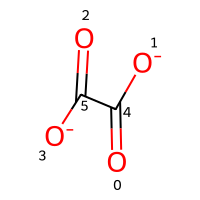

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

using rdDetermineBonds by reading xyz


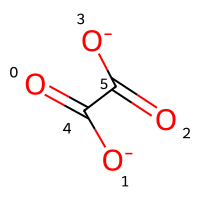

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

using rdDetermineBonds by reading xyz


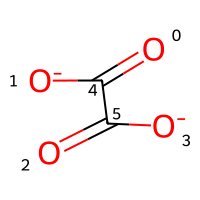

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol


Molecule 1: H24-C12-O6
using rdDetermineBonds by reading xyz


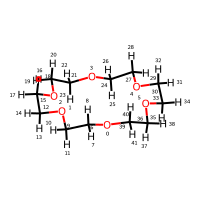

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

H24-C12-O6 H24-C12-O6 True

Molecule 2: H2-O
using rdDetermineBonds by reading xyz


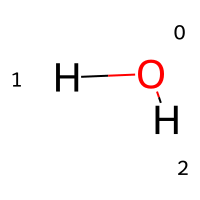

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

H2-O H2-O True

Molecule 3: H2-O
using rdDetermineBonds by reading xyz


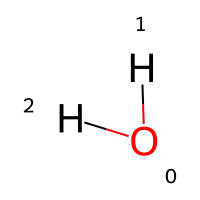

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

H2-O H2-O True

Molecule 4: H2-O
using rdDetermineBonds by reading xyz


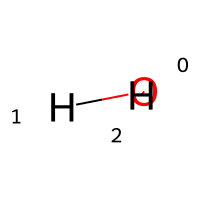

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

H2-O H2-O True

Molecule 5: H24-C12-O6
using rdDetermineBonds by reading xyz


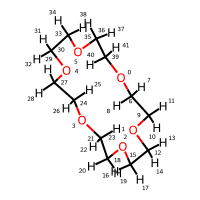

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

H24-C12-O6 H24-C12-O6 True

Molecule 6: H24-C12-O6
using rdDetermineBonds by reading xyz


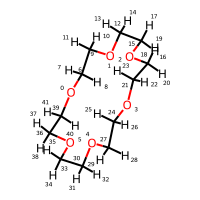

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

H24-C12-O6 H24-C12-O6 True

Molecule 7: K
using rdDetermineBonds by reading xyz


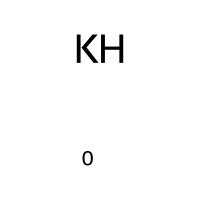

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

K K True

Molecule 8: K
using rdDetermineBonds by reading xyz


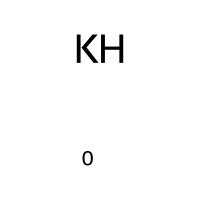

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

K K True

Molecule 9: K
using rdDetermineBonds by reading xyz


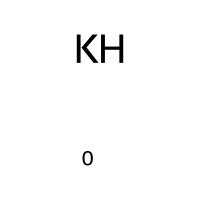

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

K K True



In [52]:
from cell2mol.connectivity import compare_species, compare_metals
from cell2mol.charge_assignment import check_rdkit_obj_connectivity, arrange_data_for_reorder

fdir = f"{folder}/{name}"

for idx, ref in enumerate(refcell.refmoleclist):
    print(f"Molecule {idx}: {ref.formula}")
    if ref.iscomplex:
        for jdx, lig in enumerate(ref.ligands):
            for specie in refcell.unique_species:
                if specie.subtype == "ligand":
                    issame = compare_species(lig, specie)
                    if issame:
                        # set_charge_state(specie, lig)
                        # print(lig.formula, specie.formula, issame)
                        print("using rdDetermineBonds by reading xyz")
                        fname = f"Ref_Molecule_{idx}_{lig.formula}_{jdx}.xyz"
                        using_rdDetermineBonds(specie, lig, fdir, fname)
                    
                        
        for met in ref.metals:
            for specie in refcell.unique_species:
                if specie.subtype == "metal":
                    issame = compare_metals(met, specie)
                    if issame:
                        met.set_charge(specie.charge)
                        # print(met.formula, specie.formula, issame) 
    else:
        for specie in refcell.unique_species:  
            if specie.subtype == "molecule":
                issame = compare_species(ref, specie)
                if issame:
                    # set_charge_state(specie, ref)
                    print("using rdDetermineBonds by reading xyz")
                    fname = f"Ref_Molecule_{idx}_{ref.formula}.xyz"
                    using_rdDetermineBonds(specie, ref, fdir, fname)
                    #print(ref.formula, specie.formula, issame)
    print("")

In [31]:
def prepare_mol (mol):
    tmp_atcharge = np.zeros((mol.natoms))
    tmp_smiles = []
    
    for lig in mol.ligands: 
        tmp_smiles.append(lig.smiles)
        parent_indices = lig.get_parent_indices("molecule")
        for kdx, a in enumerate(parent_indices):
            tmp_atcharge[a] = lig.atomic_charges[kdx]
    
    for met in mol.metals:  
        parent_index = met.get_parent_index("molecule")
        tmp_atcharge[parent_index] = met.charge  
    mol.set_charges(int(sum(tmp_atcharge)), atomic_charges=tmp_atcharge, smiles=tmp_smiles)

CELL.CREATE_BONDS: Creating Bonds for molecule C6-O12-Fe
CREATE_bonds_specie: specie.formula='C2-O4', specie.subtype='ligand'
	Number of atoms in ligand object and RDKit object are equal: 6 6
	idx=0 O Number of bonds : 1
	BOND CREATED 0 0 4 2.0 O C
	BONDS [('O', 'C', 2.0, 1.219)]
	idx=1 O Number of bonds : 1
	BOND CREATED 1 1 4 1.0 O C
	BONDS [('O', 'C', 1.0, 1.28)]
	idx=2 O Number of bonds : 1
	BOND CREATED 2 2 5 2.0 O C
	BONDS [('O', 'C', 2.0, 1.273)]
	idx=3 O Number of bonds : 1
	BOND CREATED 3 3 5 1.0 O C
	BONDS [('O', 'C', 1.0, 1.213)]
	idx=4 C Number of bonds : 3
	BOND CREATED 4 4 0 2.0 C O
	BOND CREATED 4 4 1 1.0 C O
	BOND CREATED 4 4 5 1.0 C C
	BONDS [('C', 'O', 2.0, 1.219), ('C', 'O', 1.0, 1.28), ('C', 'C', 1.0, 1.554)]
	idx=5 C Number of bonds : 3
	BOND CREATED 5 5 2 2.0 C O
	BOND CREATED 5 5 3 1.0 C O
	BOND CREATED 5 5 4 1.0 C C
	BONDS [('C', 'O', 2.0, 1.273), ('C', 'O', 1.0, 1.213), ('C', 'C', 1.0, 1.554)]
CREATE_bonds_specie: specie.formula='C2-O4', specie.subtype='ligand'

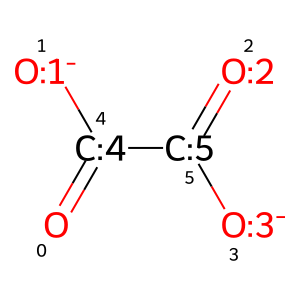

ligand.formula='C2-O4' smiles='O=C([O-])C(=O)[O-]'


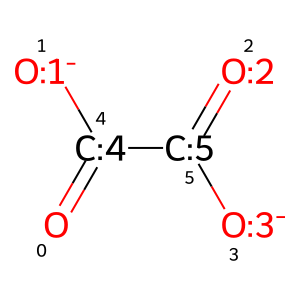

ligand.formula='C2-O4' smiles='O=C([O-])C(=O)[O-]'


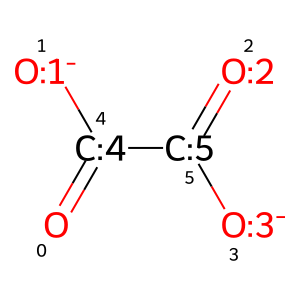

CELL.CREATE_BONDS: Creating Bonds for molecule H24-C12-O6
CREATE_bonds_specie: specie.formula='H24-C12-O6', specie.subtype='molecule'
	Number of atoms in molecule object and RDKit object are equal: 42 42
	idx=0 O Number of bonds : 2
	BOND CREATED 0 0 6 1.0 O C
	BOND CREATED 0 0 39 1.0 O C
	BONDS [('O', 'C', 1.0, 1.417), ('O', 'C', 1.0, 1.423)]
	idx=1 O Number of bonds : 2
	BOND CREATED 1 1 9 1.0 O C
	BOND CREATED 1 1 12 1.0 O C
	BONDS [('O', 'C', 1.0, 1.423), ('O', 'C', 1.0, 1.419)]
	idx=2 O Number of bonds : 2
	BOND CREATED 2 2 15 1.0 O C
	BOND CREATED 2 2 18 1.0 O C
	BONDS [('O', 'C', 1.0, 1.411), ('O', 'C', 1.0, 1.415)]
	idx=3 O Number of bonds : 2
	BOND CREATED 3 3 21 1.0 O C
	BOND CREATED 3 3 24 1.0 O C
	BONDS [('O', 'C', 1.0, 1.423), ('O', 'C', 1.0, 1.416)]
	idx=4 O Number of bonds : 2
	BOND CREATED 4 4 27 1.0 O C
	BOND CREATED 4 4 30 1.0 O C
	BONDS [('O', 'C', 1.0, 1.4), ('O', 'C', 1.0, 1.409)]
	idx=5 O Number of bonds : 2
	BOND CREATED 5 5 33 1.0 O C
	BOND CREATED 5 5 36 1.0 O 

In [34]:
refcell.create_bonds(debug=debug)

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge                 = -3
 Smiles                       = ['O=C([O-])C(=O)[O-]', 'O=C([O-])C(=O)[O-]', 'O=C([O-])C(=O)[O-]']
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------

mol.formula='C6-O12-Fe' smiles='O=C1[O-]~[Fe+3]23(~O=C1[O-])(~O=C([O-])C(=O)[O-]~2)~O=C([O-])C(=O)[O-]~3'


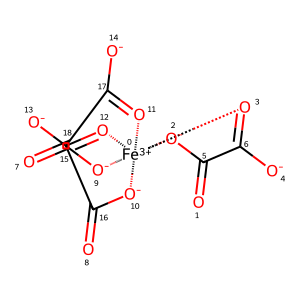

O=C1[O-]~[Fe+3]23(~O=C1[O-])(~O=C([O-])C(=O)[O-]~2)~O=C([O-])C(=O)[O-]~3


You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-O6
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge                 = 0
 Smiles                       = [H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC1([H])[H]
---------------------------------------------------

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 3
 Formula                      = H2-O
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge                 = 0
 Smil

In [47]:
from cell2mol.charge_assignment import get_smiles_complex

for ref in refcell.refmoleclist:
    if ref.iscomplex :
        prepare_mol(ref)
        print(ref)
        smiles, obj = get_smiles_complex(ref, debug=1)
        print(smiles)
        draw_with_spheres(obj)
        # for lig in ref.ligands:
        #     print(lig)
        # for met in ref.metals:
        #     print(met)
    else :
        print(ref)

In [58]:
refcell

------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = reference
 Name (Refcode)        = BOFFOS
 Num Atoms             = 157
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
---------------------------------------------------
 # of Ref Molecules:   = 10
 With Formulae:                                  
    0: C6-O12-Fe 
    1: H24-C12-O6 
    2: H2-O 
    3: H2-O 
    4: H2-O 
    5: H24-C12-O6 
    6: H24-C12-O6 
    7: K 
    8: K 
    9: K 

In [53]:
for ref in refcell.refmoleclist:
    print(ref)

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge                 = -3
 Smiles                       = ['O=C([O-])C(=O)[O-]', 'O=C([O-])C(=O)[O-]', 'O=C([O-])C(=O)[O-]']
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-O6
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge                 = 0


In [54]:
refcell.save(f"{folder}/{name}/Ref_Cell_{name}_NEW.cell")

SAVING cell2mol CELL object to error_2/BOFFOS/Ref_Cell_BOFFOS_NEW.cell
